# Lab 01: Fitting a Line When Your Data Are Lying to You

**ASTR 457, Fall 2026 — posted Thu Sep 3, due Wed Sep 9 by Noon (fork → PR, as always)**

*Why this lab: fitting a line to contaminated data is the statistic behind real discoveries (it's how Gaia BH1's dark companion was found), and refereeing someone else's fit — including a machine's — is the skill you'll use in every collaboration, every review, and every AI-assisted analysis for the rest of your career.*

Every one of you has your own dataset: `data/<your netid>.csv`, with columns `x`, `y`, `sigma_y`.
It was generated from a straight line, $y = mx + b$, with Gaussian noise of the stated
$\sigma_y$ — except that some fraction of the points are **outliers** drawn from a much
broader distribution. I know the true $m$, $b$, and outlier fraction for your dataset.
You don't, and you can't look them up, and your classmates' values are different from yours.

**How this is graded.** Not on whether your code runs — on whether your answers are *right*
and your uncertainties are *honest*. Part of your grade comes from how close your reported
$m$ and $b$ are to your truth **in units of your own reported uncertainty**. Report tiny
error bars you can't back up and you will lose points even if your central value is close.
Report huge error bars to be safe and you'll lose points too. Calibration is the skill.

**AI policy reminder.** Use whatever tools you like, including AI assistants — and document
it in Part 4. You may be selected to defend this lab in person. Welcome to doing research.

## Part 1: The naive fit (20%)

Load your dataset and fit a straight line by **weighted least squares**, using the reported
`sigma_y` and all the data points. Report $m \pm \sigma_m$ and $b \pm \sigma_b$, plot the
data (with error bars) and your fit, and compute the reduced $\chi^2$.

Then answer, in a few sentences: what is the reduced $\chi^2$ telling you, and why is it
doing that? Would you trust these error bars? (This fit is *supposed* to be bad. Understanding
exactly how it is bad is the point.)

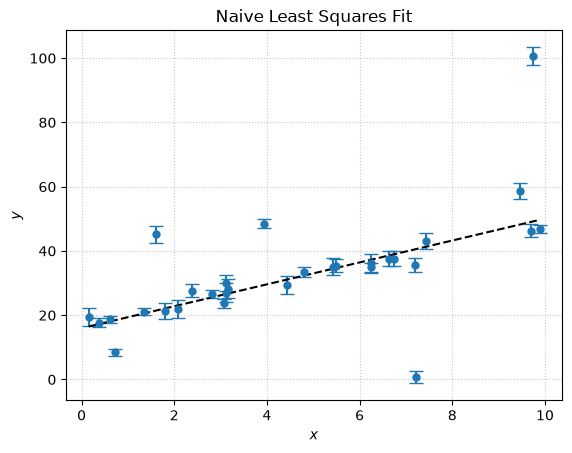

Naive fit slope: m = 3.4091 +/- 0.1067
Naive fit intercept: b = 15.9693 +/- 0.5399
Naive reduced chi squared: 40.5511


In [1]:
# Part 1: your work here
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

def f(x, m, b):
    return m * x + b

datafile = "./data/ahuwer2.csv"
data = pd.read_csv(datafile)
x = data['x']
y = data['y']
sigma_y = data['sigma_y']
#print(data)

popt, pcov = curve_fit(f, x, y, sigma=sigma_y, absolute_sigma=True)
m, b = popt
sigma_m, sigma_b = np.sqrt(np.diag(pcov))

plt.errorbar(x, y, sigma_y, fmt='o', capsize=5, markersize=5)
plt.plot(x, m*x + b, color='k', linestyle='--')
plt.grid(True, alpha=0.7, linestyle=':')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.title('Naive Least Squares Fit')
plt.show()

print(f'Naive fit slope: m = {m:.4f} +/- {sigma_m:.4f}')
print(f'Naive fit intercept: b = {b:.4f} +/- {sigma_b:.4f}')

residuals = y - f(x, m, b)
chi2 = np.sum((residuals / sigma_y) ** 2)
red_chi2 = chi2 / (len(x) - 2)
print(f'Naive reduced chi squared: {red_chi2:.4f}') 

**ANSWER (a few sentences):**

The reduced-$\chi^2$ value that I got is very high, which indicates a pretty bad fit, or a bad choice of errors. In this case, it's a bit of a mix of both. As seen in my code above, $\chi^2$ is calculated by summing the squared residuals over the squared errors. Since we can clearly see from the figure above that the uncertainties are too small **and** we are also including outliers (which result in higher residuals for those points), we have two separate factors which are increasing the value of $\chi^2$ and the reduced-$\chi^2$. Both the plot and the reduced-$\chi^2$ make it clear that these error bars should not be trusted.

## Part 2: A fit you can defend (40%)

Now deal with the outliers. Do this **two ways**:

1. **Sigma-clipping**: iteratively remove points that are discrepant with the fit, refit,
   and repeat until it converges. Be explicit about your clipping threshold and why you chose it.
2. **A mixture model**: model each point as coming from either the line (with its stated
   $\sigma_y$) or from a broader outlier distribution, and maximize the appropriate likelihood
   (see Hogg, Bovy & Lang 2010, §3, for the canonical treatment — this is the same problem
   with different numbers).

For each method report $m \pm \sigma_m$, $b \pm \sigma_b$, and (for the mixture) your
estimate of the outlier fraction. Then commit to a **final answer** — one set of numbers
you'd put in a paper — and justify the choice. State clearly how you estimated your
uncertainties and why you believe them.

k-clipped fit slope: m = 3.0029 +/- 0.1218
k-clipped fit intercept: b = 17.2965 +/- 0.6182
k-clipped reduced chi squared: 0.8148


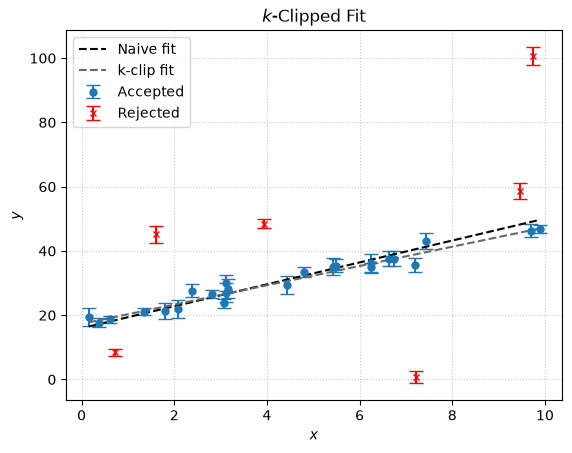

Mixture model fit slope: m = 3.0034 +/- 0.1003
Mixture model fit intercept: b = 17.2974 +/- 0.5097
Outlier fraction: Pb = 0.2217


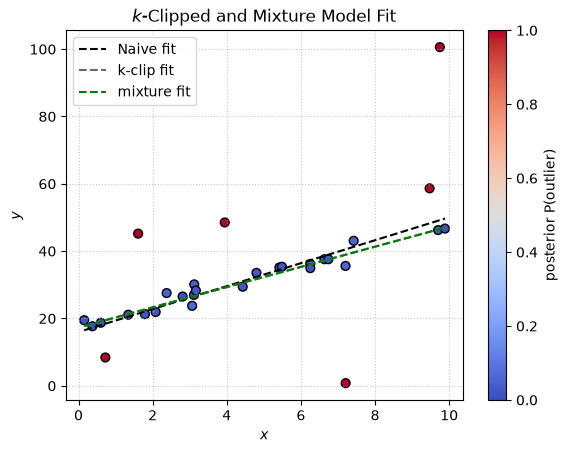

In [2]:
# Part 2: your work here
from scipy.optimize import minimize
from scipy.stats import norm

### Sigma clipping ###
def k_sigma(xs, ys, sigmas, k, max_it=100):
    mask = np.full(len(xs), True)
    finished = False
    it = 0
    while not finished and it < max_it:
        popt, pcov = curve_fit(f, xs[mask], ys[mask], sigma=sigmas[mask], absolute_sigma=True)
        m, b = popt
        sigma_m, sigma_b = np.sqrt(np.diag(pcov))
        
        residuals = (ys - (m*xs + b)) / sigmas
        prev_mask = mask
        mask = np.abs(residuals) < k
        if np.array_equal(prev_mask, mask):
            finished = True
        it += 1
    return m, b, sigma_m, sigma_b, mask

# I chose 3 sigma here as I know that to be a general good starting point for sigma clipping, 
# and it manages to ignore all the major, basically certain outliers. There are a few points
# along the main population which lie just outside error and could potentially be excluded,
# but they all seem to be from the same population and I can't be certain that they aren't
# real data (plus I have to lower the clipping to around 2 sigma for that, which would 
# theoretically ignore 5% of valid data. 2 sigma cuts out 1/24 points included with 3 sigma,
# so that about matches up, another reason why I stuck with 3 sigma).
m_k, b_k, sigma_m_k, sigma_b_k, mask = k_sigma(x, y, sigma_y, 3)

#print(sum(mask))
print(f'k-clipped fit slope: m = {m_k:.4f} +/- {sigma_m_k:.4f}')
print(f'k-clipped fit intercept: b = {b_k:.4f} +/- {sigma_b_k:.4f}')

residuals_k = y[mask] - f(x[mask], m_k, b_k)
chi2_k = np.sum((residuals_k / sigma_y[mask]) ** 2)
red_chi2_k = chi2_k / (len(x[mask]) - 2)
print(f'k-clipped reduced chi squared: {red_chi2_k:.4f}') 

plt.errorbar(x[mask], y[mask], sigma_y[mask], fmt='o', capsize=5, markersize=5, label='Accepted')
plt.errorbar(x[~mask], y[~mask], sigma_y[~mask], fmt='x', capsize=5, markersize=5, color='r', label='Rejected')
plt.plot(x, m*x + b, 'k--', label='Naive fit')
plt.plot(x, m_k*x + b_k, color='dimgrey', linestyle='--', label='k-clip fit')
plt.grid(True, alpha=0.7, linestyle=':')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.title('$k$-Clipped Fit')
plt.legend()
plt.show()

### Mixture model ###
def neg_log_likelihood(theta, x, y, sigma):
    m, b, Pb, Yb, lnVb = theta
    Pb = np.clip(Pb, 1e-6, 1 - 1e-6)
    Vb = np.exp(lnVb)
    model = m * x + b
    good = (1 - Pb) * norm.pdf(y, loc=model, scale=sigma)
    bad_pop = Pb * norm.pdf(y, loc=Yb, scale=np.sqrt(Vb + sigma**2))
    return -np.sum(np.log(good + bad_pop + 1e-300))

theta0 = [m_k, b_k, 0.2, np.mean(y), np.log(50.0)]
result = minimize(neg_log_likelihood, theta0, args=(x, y, sigma_y), method='Nelder-Mead')
m_mix, b_mix, Pb_mix, Yb_mix, lnVb_mix = result.x

# bootstrap to find errors, takes a while with n_boot = 1000 but worth it
# also add rng seed here so the results are consistent with my statement in text below
rng = np.random.default_rng(seed=1)
n_boot = 1000
m_boot = []
b_boot = []
n = len(x)
for i in range(n_boot):
    idx = rng.choice(n, n)
    res = minimize(neg_log_likelihood, theta0, args=(x[idx], y[idx], sigma_y[idx]), method='Nelder-Mead')
    m_boot.append(res.x[0])
    b_boot.append(res.x[1])
sigma_m_boot = np.std(m_boot)
sigma_b_boot = np.std(b_boot)

print(f'Mixture model fit slope: m = {m_mix:.4f} +/- {sigma_m_boot:.4f}')
print(f'Mixture model fit intercept: b = {b_mix:.4f} +/- {sigma_b_boot:.4f}')
print(f'Outlier fraction: Pb = {Pb_mix:.4f}')
Vb_mix = np.exp(lnVb_mix)
model_mix = m_mix * x + b_mix
good_l = (1 - Pb_mix) * norm.pdf(y, loc=model_mix, scale=sigma_y)
bad_l = Pb_mix * norm.pdf(y, loc=Yb_mix, scale=np.sqrt(Vb_mix + sigma_y**2))
p_bad = bad_l / (good_l + bad_l)

plt.plot(x, m*x + b, 'k--', label='Naive fit')
plt.plot(x, m_k*x + b_k, color='dimgrey', linestyle='--', label='k-clip fit')
plt.scatter(x, y, c=p_bad, cmap='coolwarm', s=40, edgecolor='k', vmin=0, vmax=1)
plt.colorbar(label='posterior P(outlier)')
plt.plot(x, m_mix * x + b_mix, 'g--', label='mixture fit')
plt.grid(True, alpha=0.7, linestyle=':')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.title('$k$-Clipped and Mixture Model Fit')
plt.legend()
plt.show()

**FINAL ANSWER:** $m = 3.0034\pm0.1003$, $b =17.2974 \pm0.5097$, outlier fraction $\approx0.2217$

**Justification and uncertainty method (a short paragraph):**

I believe that the mixture model is most accurate in this case. Both models give extremely similar results, differing only in the thousandths place for the main values, which is a fairly good indication that the models are similarly accurate. However, we can see that the $k$-clip fit is not only less general (i.e. if I changed the dataset, I'd have to manually adjust the value of $k$ until I got something reasonable, which could be hard to visualize given a large enough dataset), but also has slightly larger uncertainties. Also, since we used bootstrapping to determine the uncertainties in the mixture model case, I'm a bit more confident in those uncertainties being more accurate/robust than in the $k$-clipped case anyways.

## Part 3: The referee report (30%)

The file `ai_solution.ipynb` in this directory is a complete, tidy, confident analysis of
this exact problem, produced by an AI assistant. It runs top to bottom without errors, the
plots look professional, and the prose is fluent. It is also wrong — in at least **three**
distinct, substantive ways (cosmetic nitpicks don't count).

Write a referee report:

1. **Identify** at least three substantive statistical errors.
2. **Demonstrate** each one quantitatively on *your* dataset — show, with a number or a plot,
   what the error does to the inference. "This is bad practice" is not a demonstration.
3. **State** what the correct treatment is (you already built it in Part 2).

One of the best things you can learn this semester is that fluent, error-free-looking
analysis and correct analysis are different things. Referee accordingly.

**REFEREE REPORT:**

*Flaw 1:* Didn't even compute the naive fit correctly. The AI forgot to pass in the inverse of the errors as weights, and so despite using a good naive fitting algorithm, its result slightly overestimates the slope, intercept, and more importantly it significantly overestimates the errors on both the slope and intercept. This directly impacts the clipping, as the inflated errors make the $3\sigma$ choice of clipping much less reasonable and as a result they only clip 2 of the outliers. See demonstration 1. The fix is simply to include these errors and weight the least squares algorithm.

*Flaw 2:* Probably the most blatant, it just rescales the errors until $\chi^2=1$ without actually addressing any of the reasons as to *why* we have a bad $\chi^2$ parameter. It just knows that $\chi^2=1$ means a good fit and it's expected to provide a good fit (why would the human give it a problem that couldn't be fit properly, after all?), so it decides to *make* it a "good fit" without really understanding that it should really be addressing the root cause. You can only really rescale the errors if you trust everything *but* the errors you were given, and here we should first be distrusting the model (especially when you can see that outliers are still included) before you try to address the $\chi^2$ issue elsewhere. See demonstration 2, which is just the plot copied from the ai solution file. You can visually see that the errors are now overestimated due to the inclusion of outliers (see flaw 1), and checking the errors it reports at the bottom shows that **NO** this is **NOT** a good fit at all. The errors roughly the size of the actual values (up to $\pm18.1638$ for $b$), which is really bad, especially compared against my results from above which show errors on the order of a few tenths. The fix for this would also be to correct the naive case so the $k$-clipping actually functioned using appropriate $\sigma$ values, or to use a mixture model approach as we also tried.

*Flaw 3:* The AI also made a mistake in the actual $k$-clipping algorithm, it only did one iteration which maybe could be fine on some datasets, but in general is a bit of a bad idea. You shouldn't be counting the outliers in the standard deviation when trying to remove those outliers, as you want to remove what's outside $3\sigma$ (or equivalent choice of threshold) of the *actual* data. If you find $\sigma$ once at the start, it will be artificially high due to outliers and thus may only clip a few outliers at first. This is why we iterated that step above, as without it we wouldn't remove all the outliers. It's also clipping based on a global std and not the given $\sigma$s, but I count that as a separate issue. See demonstration 3, which uses my code from above but only iterates once instead of repeatedly. Unfortunately, with my dataset and choice of $k$ from earlier it doesn't make a difference and thus the demonstration is somewhat moot, but for another dataset it could be an issue.

### Demonstration 1 ####

Removed 2 outliers of 30 points
Its Slope:     m = 3.7698 +/- 0.8548
My slope:      m = 3.4091 +/- 0.1067
Its Intercept: b = 16.0293 +/- 4.6458
My intercept:  b = 15.9693 +/- 0.5399


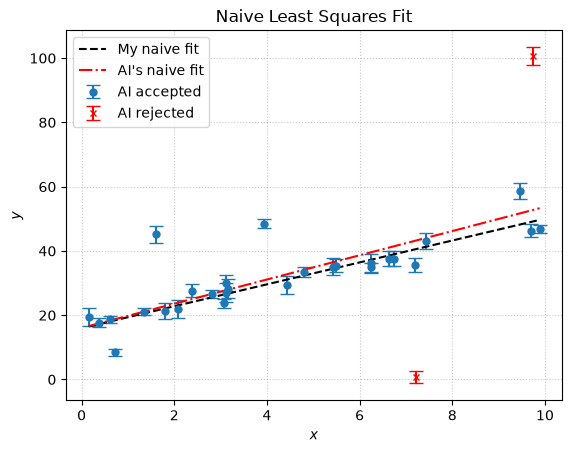


### Demonstration 2 ###

Reduced chi-squared: 15.286
After rescaling uncertainties by 3.910: reduced chi-squared = 1.000


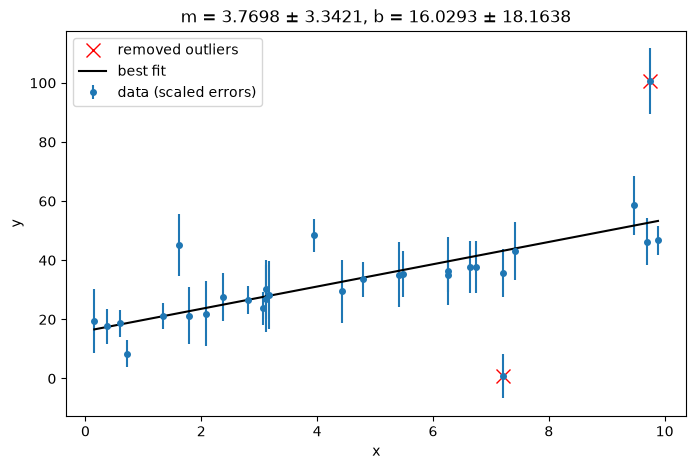

Final results:
  m = 3.7698 +/- 3.3421
  b = 16.0293 +/- 18.1638
Conclusion: the linear model provides an excellent description of the data,
with precisely determined parameters and calibrated uncertainties.

### Demonstration 3 ###

once-k-clipped fit slope: m = 3.4091 +/- 0.1067
once-k-clipped fit intercept: b = 15.9693 +/- 0.5399


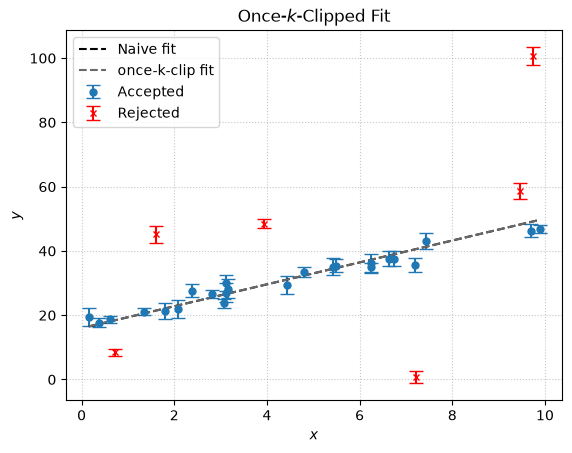

In [3]:
# Part 3: demonstrations hereimport numpy as np
NETID = 'ahuwer2'
data = np.genfromtxt(f'data/{NETID}.csv', delimiter=',', names=True)
x, y, sigma_y = data['x'], data['y'], data['sigma_y']



print('### Demonstration 1 ####\n')
coeffs, cov = np.polyfit(x, y, 1, cov=True)
m_fit, b_fit = coeffs
m_err, b_err = np.sqrt(np.diag(cov))
residuals = y - (m_fit * x + b_fit)
threshold = 3 * np.std(residuals)
mask = np.abs(residuals) < threshold

print(f"Removed {np.sum(~mask)} outliers of {len(x)} points")
print(f"Its Slope:     m = {m_fit:.4f} +/- {m_err:.4f}")
print(f'My slope:      m = {m:.4f} +/- {sigma_m:.4f}')
print(f"Its Intercept: b = {b_fit:.4f} +/- {b_err:.4f}")
print(f'My intercept:  b = {b:.4f} +/- {sigma_b:.4f}')
plt.errorbar(x[mask], y[mask], sigma_y[mask], fmt='o', capsize=5, markersize=5, label='AI accepted')
plt.errorbar(x[~mask], y[~mask], sigma_y[~mask], fmt='x', capsize=5, markersize=5, color='r', label='AI rejected')
plt.plot(x, m*x + b, color='k', linestyle='--', label='My naive fit')
plt.plot(x, m_fit*x + b_fit, color='r', linestyle='-.', label="AI's naive fit")
plt.grid(True, alpha=0.7, linestyle=':')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.title('Naive Least Squares Fit')
plt.legend()
plt.show()



print('\n### Demonstration 2 ###\n')
chi2 = np.sum(((y[mask] - (m_fit * x[mask] + b_fit)) / sigma_y[mask])**2)
dof = mask.sum() - 2
chi2_red = chi2 / dof
print(f"Reduced chi-squared: {chi2_red:.3f}")

scale = np.sqrt(chi2_red)
sigma_scaled = sigma_y * scale
chi2_new = np.sum(((y[mask] - (m_fit * x[mask] + b_fit)) / sigma_scaled[mask])**2) / dof
m_err, b_err = m_err * scale, b_err * scale
print(f"After rescaling uncertainties by {scale:.3f}: reduced chi-squared = {chi2_new:.3f}")

plt.figure(figsize=(8, 5))
plt.errorbar(x, y, yerr=sigma_scaled, fmt='o', ms=4, label='data (scaled errors)')
plt.plot(x[~mask], y[~mask], 'rx', ms=10, label='removed outliers')
xg = np.linspace(x.min(), x.max(), 100)
plt.plot(xg, m_fit * xg + b_fit, 'k-', label='best fit')
plt.xlabel('x'); plt.ylabel('y'); plt.legend()
plt.title(f'm = {m_fit:.4f} $\\pm$ {m_err:.4f}, b = {b_fit:.4f} $\\pm$ {b_err:.4f}')
plt.show()

print("Final results:")
print(f"  m = {m_fit:.4f} +/- {m_err:.4f}")
print(f"  b = {b_fit:.4f} +/- {b_err:.4f}")
print("Conclusion: the linear model provides an excellent description of the data,")
print("with precisely determined parameters and calibrated uncertainties.")



print('\n### Demonstration 3 ###\n')
# use only 1 iteration, with the same k
m_k1, b_k1, sigma_m_k1, sigma_b_k1, mask1 = k_sigma(x, y, sigma_y, 3, 1)

#print(sum(mask))
print(f'once-k-clipped fit slope: m = {m_k1:.4f} +/- {sigma_m_k1:.4f}')
print(f'once-k-clipped fit intercept: b = {b_k1:.4f} +/- {sigma_b_k1:.4f}')
plt.errorbar(x[mask1], y[mask1], sigma_y[mask1], fmt='o', capsize=5, markersize=5, label='Accepted')
plt.errorbar(x[~mask1], y[~mask1], sigma_y[~mask1], fmt='x', capsize=5, markersize=5, color='r', label='Rejected')
plt.plot(x, m*x + b, 'k--', label='Naive fit')
plt.plot(x, m_k1*x + b_k1, color='dimgrey', linestyle='--', label='once-k-clip fit')
plt.grid(True, alpha=0.7, linestyle=':')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.title('Once-$k$-Clipped Fit')
plt.legend()
plt.show()

## Part 4: AI-use appendix & verification plan (10%)

1. **AI use**: which tools did you use (Copilot, Claude, ChatGPT, none, ...), for what,
   what did they get wrong, and how did you catch it? Honesty is graded; "I didn't use any"
   is fine if true.
2. **Verification plan**: list the checks you ran before deciding to trust your Part 2
   numbers (e.g., residual plots, posterior/parameter sanity checks, refitting on synthetic
   data you generated with known answers). For each check: what would failure have looked like?

**AI-USE APPENDIX:**

* For part 1: the only AI used was the stuff that automatically comes up on Google searches now, as I was looking up the best option for least squares fitting (forgot about np.polyfit from class until I reviewed the lecture in part 2, but just decided to stick with scipy.curve_fit as it also uses least squares and conveniently has a sigma input rather than a weights input.

* For part 2: I used Claude to help debug an error quickly (I accidentally wrote (y - m * x + b) / sigma instead of (y - (m * x + b)) / sigma, oops), and to help me better understand the lecture's implementation of the mixtures model. I verified its change was right by using common sense (it was just a slight error I didn't notice for a bit). But I also verified that with that change, the high residuals I was getting went back down enough to not remove every single point from the mask upon the first iteration, which was another indicator that that parentheses mistake was the root issue. Similarly to part 1, also used Google's built-in AI response when searching for a good way to randomly sample indexes with replacement (confirmed by checking the np.random.choice doc, it does default to replace=True). Also used Claude to help me understand the inputs of scipy.stats.probplot (the doc simply states x: Sample/response data from which probplot creates the plot, which was not at all helpful for me) so I could make the QQ plot (see below) for the verification part of this.

* For part 3: no AI was used.

**VERIFICATION PLAN:**

I mainly verified with a QQ plot (see below) to make sure the mixture model is the right approach (the data can be modeled as two separate gaussian distributions). As I saw and talked about in part 2, the results from both models were very similar and seemingly accurate to the dataset ignoring the outliers. The values each obtained were very similar, so if I can show that the assumptions for my main choice of the mixture model are correct on this dataset, I can be relatively certain my values are accurate in both cases. As seen below, the plots behave mostly linearly as expected (there is some scatter but it's expected for a small dataset and nothing nearly as significant as we saw in lecture for the Cauchy distribution). If it weren't linear and, for instance, had significantly curved tails on either end, we could say that the assumptions used for the mixture model don't hold and that would be an improper approach. But it does seem to hold, thus we can be fairly certain that modeling this as two separate gaussian distributions is correct. This backs up the visual check of just seeing if it looks reasonable and the selected outliers make sense to be removed.

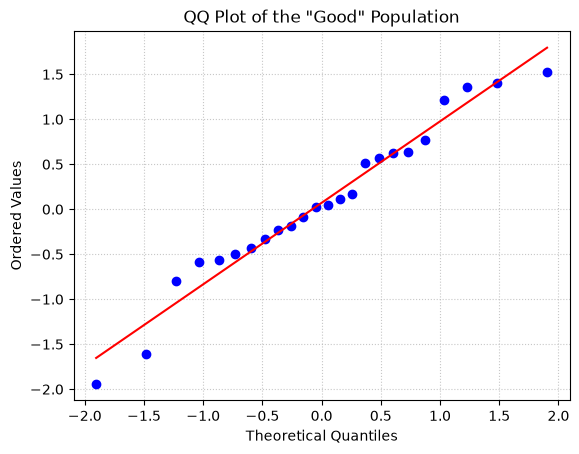

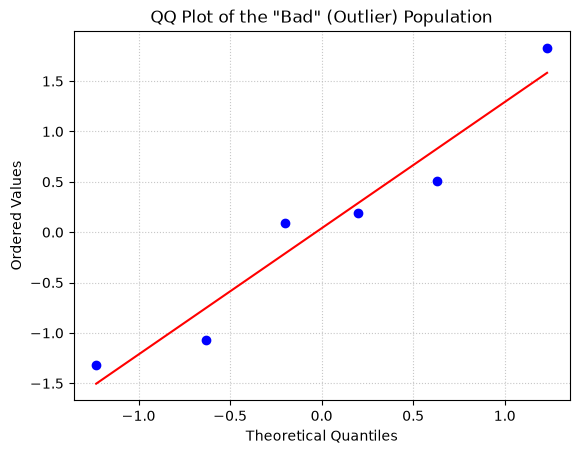

In [12]:
import scipy.stats as stats

is_good = p_bad < 0.5
is_bad = p_bad >= 0.5

z_good = (y[is_good] - (m_mix * x[is_good] + b_mix)) / sigma_y[is_good]
z_bad = (y[is_bad] - Yb_mix) / np.sqrt(Vb_mix + sigma_y[is_bad]**2)

# QQ for good pop
fig, ax = plt.subplots(1,1)
stats.probplot(z_good, dist="norm", plot=ax)
plt.grid(True, alpha=0.7, linestyle=':')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Ordered Values')
plt.title('QQ Plot of the "Good" Population')
plt.show()

# QQ for outlier pop
fig, ax = plt.subplots(1,1)
stats.probplot(z_bad, dist="norm", plot=ax)
plt.grid(True, alpha=0.7, linestyle=':')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Ordered Values')
plt.title('QQ Plot of the "Bad" (Outlier) Population')
plt.show()